# 🎬 El Secreto de sus Ojos — Arquitectura Agent2Agent (A2A)

4 sub-agentes especializados registrados en un `RegistroA2A`, coordinados por un supervisor orquestador implementado como `StateGraph`.

```
Supervisor (StateGraph)
    │
    ├── [A2A message/send] → Agente Sacerdote
    ├── [A2A message/send] → Agente Crítico       (recibe output del sacerdote)
    ├── [A2A message/send] → Agente Meta-Crítico  (recibe output del crítico)
    └── [A2A message/send] → Agente Juez          (consolida todo en JSON)
```

Cada agente:
- Tiene su propia **Agent Card** (nombre, skills, capacidades)
- Se comunica vía protocolo **A2A** (`message/send` → `task/completed`)
- Es un `create_react_agent` con tools propios
- Tiene su propia memoria (`InMemorySaver` con `thread_id`)


In [2]:
%pip install -q langchain-classic langchain-openai langchain-core langgraph python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ── IMPORTS ───────────────────────────────────────────────────
import json
import uuid
import logging
from typing import List, Optional, Literal
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import InMemorySaver
from pydantic import BaseModel, Field
from IPython.display import display, Markdown, Image
from dotenv import load_dotenv
import os

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    force=True,
)
logger = logging.getLogger("SecretoOjosA2A")



load_dotenv()

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
print("OPENAI_API_KEY cargada correctamente.")

def make_llm():
    """Cada agente tiene su propia instancia de LLM."""
    return ChatOpenAI(
        model="gpt-4o-mini",
        openai_api_key=OPENAI_API_KEY,
        max_tokens=2000,
    )

logger.info("Setup completo")
print("✅ Setup OK")

2026-03-05 21:02:26,057 - SecretoOjosA2A - INFO - Setup completo


OPENAI_API_KEY cargada correctamente.
✅ Setup OK


---
## 1. Schema Pydantic — Output estructurado del Juez

In [5]:
# ── SCHEMA ────────────────────────────────────────────────────

class Incoherencia(BaseModel):
    id: str = Field(description="Identificador único, ej: INC-001")
    descripcion: str
    categoria: Literal["logica", "juridica", "narrativa", "moral", "historica"]
    severidad: Literal["leve", "moderada", "grave"]
    escena_referencia: Optional[str] = None


class VeredictFinal(BaseModel):
    pelicula: str
    ganador: Literal["sacerdote", "critico", "empate"]
    justificacion: str
    incoherencias_confirmadas: List[Incoherencia]
    incoherencias_descartadas: List[str]
    score_sacerdote: int = Field(description="0-10")
    score_critico: int = Field(description="0-10")
    reflexion_final: str

print("✅ Schema OK")

✅ Schema OK


---
## 2. Tools — uno por sub-agente

Cada agente tiene tools específicos para su rol.

In [6]:
# ── TOOLS DEL SACERDOTE ───────────────────────────────────────

@tool
def evaluar_dilema_moral(situacion: str) -> str:
    """Evalúa el peso moral de una situación en la película desde ética teológica."""
    db = {
        "morales carcelero": (
            "DILEMA GRAVE: Morales ejerce una justicia privada que la Iglesia condena. "
            "La venganza pertenece a Dios, no al hombre. Sin embargo, el Estado falló primero."
        ),
        "esposito silencio": (
            "COMPLICIDAD MORAL: Espósito calla ante un crimen que presenció. "
            "El silencio ante la injusticia es también una forma de injusticia."
        ),
        "sandoval sacrificio": (
            "VACÍO MORAL: La película no tematiza la culpa de Espósito por la muerte de Sandoval. "
            "Ese olvido narrativo es una incoherencia ética importante."
        ),
        "impunidad estado": (
            "DENUNCIA VÁLIDA: La impunidad estatal que protege a Gómez es un mal estructural. "
            "Éticamente justifica la desesperación de Morales, aunque no sus medios."
        ),
    }
    return db.get(situacion.lower().strip(),
        f"Situación '{situacion}' no encontrada. Disponibles: {', '.join(db.keys())}")


@tool
def evaluar_libre_albedrio(decision: str) -> str:
    """Analiza si una decisión de un personaje respeta o contradice el libre albedrío."""
    db = {
        "morales encierro": (
            "CONTRADICCIÓN: Morales priva a Gómez del libre albedrío — la misma dignidad "
            "que Gómez negó a su esposa. La simetría es poética pero éticamente problemática."
        ),
        "esposito partir": (
            "INCOHERENCIA: Espósito se va a Buenos Aires en parte por cobardía emocional. "
            "Su 'elección' de exiliarse es una huida disfrazada de decisión libre."
        ),
    }
    return db.get(decision.lower().strip(),
        f"Decisión '{decision}' no encontrada. Disponibles: {', '.join(db.keys())}")


# ── TOOLS DEL CRÍTICO ─────────────────────────────────────────

@tool
def verificar_coherencia_narrativa(escena: str) -> str:
    """Verifica si una escena o elemento narrativo tiene coherencia interna."""
    db = {
        "muerte sandoval": (
            "INCOHERENCIA MODERADA: Los sicarios llegan al depto de Sandoval porque "
            "Espósito le prestó su casa. La película nunca explica cómo obtuvieron esa dirección."
        ),
        "giro celda": (
            "AGUJERO DE GUIÓN: Mantener a alguien encerrado 25 años requiere infraestructura, "
            "recursos y silencio absoluto. Nada de esto está explicado en el guión."
        ),
        "amor no confesado": (
            "INVEROSÍMIL PSICOLÓGICAMENTE: Dos adultos inteligentes con tensión romántica "
            "evidente que no hablan del tema en 25 años. Funciona como metáfora, falla como realismo."
        ),
        "obsesion futbol": (
            "SÓLIDO NARRATIVAMENTE: La deducción por la pasión futbolística es "
            "el punto narrativo más fuerte del film. Psicológicamente verosímil."
        ),
        "escena estadio": (
            "BRILLANTE TÉCNICAMENTE, FORZADA NARRATIVAMENTE: El plano secuencia es extraordinario, "
            "pero el arresto en pleno estadio sin respaldo institucional formal es cuestionable."
        ),
    }
    return db.get(escena.lower().strip(),
        f"Escena '{escena}' no encontrada. Disponibles: {', '.join(db.keys())}")


@tool
def verificar_hecho_juridico(concepto: str) -> str:
    """Verifica si un hecho jurídico o procesal de la película es realista."""
    db = {
        "liberacion gomez": (
            "CONTEXTUALMENTE VÁLIDO: La liberación por ser informante de la Triple A "
            "es históricamente plausible para 1974."
        ),
        "prision privada": (
            "ILEGAL: Privación ilegal de la libertad + tortura psicológica. "
            "No existe marco legal que lo justifique."
        ),
        "novela esposito": (
            "LEGALMENTE PROBLEMÁTICO: Publicar un expediente judicial real con nombres reales "
            "violaría el secreto sumarial y la privacidad de las partes."
        ),
    }
    return db.get(concepto.lower().strip(),
        f"Concepto '{concepto}' no encontrado. Disponibles: {', '.join(db.keys())}")


# ── TOOLS DEL META-CRÍTICO ────────────────────────────────────

@tool
def detectar_sesgo_analitico(analisis: str) -> str:
    """Detecta sesgos o falacias en un análisis cinematográfico previo."""
    db = {
        "sesgo moralista": (
            "SESGO DETECTADO: Juzgar decisiones de personajes de ficción con vara moral "
            "absoluta ignora que la película opera en un registro trágico, no moralizante. "
            "La ambigüedad moral ES el punto."
        ),
        "sesgo realista": (
            "SESGO DETECTADO: Exigir coherencia realista absoluta a un film que es "
            "deliberadamente melodramático ignora su género. "
            "El amor no confesado en 25 años ES una elección narrativa consciente."
        ),
        "sesgo juridico": (
            "SESGO PARCIALMENTE VÁLIDO: Señalar incoherencias jurídicas es legítimo, "
            "pero la película no pretende ser un documental legal. "
            "El contexto de impunidad histórica justifica las licencias narrativas."
        ),
    }
    return db.get(analisis.lower().strip(),
        f"Sesgo '{analisis}' no encontrado. Disponibles: {', '.join(db.keys())}")


@tool
def evaluar_intencion_artistica(elemento: str) -> str:
    """Evalúa si algo que parece una incoherencia es en realidad una decisión artística."""
    db = {
        "amor no declarado": (
            "DECISIÓN ARTÍSTICA: El amor no declarado en 25 años es una metáfora del caso "
            "sin resolver. Espósito no puede cerrar ninguno de los dos. Es coherente "
            "temáticamente aunque inverosímil psicológicamente."
        ),
        "celda morales": (
            "MIXTO: El giro de la celda funciona como símbolo (el vacío es la peor condena), "
            "pero los agujeros logísticos son reales. Campanella privilegió el impacto "
            "emocional sobre la verosimilitud. Decisión válida pero discutible."
        ),
        "culpa esposito sandoval": (
            "INCOHERENCIA REAL: El film nunca tematiza que Espósito tiene responsabilidad "
            "en la muerte de Sandoval. Esto NO es una decisión artística — es un vacío "
            "emocional del guión que debilita el arco del protagonista."
        ),
    }
    return db.get(elemento.lower().strip(),
        f"Elemento '{elemento}' no encontrado. Disponibles: {', '.join(db.keys())}")


# ── TOOLS DEL JUEZ ────────────────────────────────────────────

@tool
def consolidar_incoherencias(categoria: str) -> str:
    """Consolida las incoherencias más relevantes por categoría para el veredicto final."""
    db = {
        "moral": (
            "TOP INCOHERENCIAS MORALES: "
            "1) Espósito no procesa su culpa por Sandoval. "
            "2) Espósito calla ante la prisión ilegal de Morales. "
            "3) Irene como jueza tampoco actúa."
        ),
        "narrativa": (
            "TOP INCOHERENCIAS NARRATIVAS: "
            "1) Los sicarios obtienen la dirección de Sandoval sin explicación. "
            "2) El amor no confesado en 25 años es inverosímil. "
            "3) Los agujeros logísticos de la celda privada de Morales."
        ),
        "juridica": (
            "TOP INCOHERENCIAS JURÍDICAS: "
            "1) La prisión privada de Morales es un crimen grave sin consecuencias. "
            "2) La novela de Espósito expone información de un expediente real. "
            "3) El arresto en el estadio sin orden judicial formal."
        ),
    }
    return db.get(categoria.lower().strip(),
        f"Categoría '{categoria}' no encontrada. Disponibles: {', '.join(db.keys())}")


logger.info("Tools definidos")
print("✅ Tools OK")

2026-03-05 21:02:41,747 - SecretoOjosA2A - INFO - Tools definidos


✅ Tools OK


---
## 3. Sub-agentes + Agent Cards

Cada agente tiene su `Agent Card` y es un `create_react_agent` con tools propios y memoria independiente.

In [7]:
# ── AGENT CARDS ───────────────────────────────────────────────

AGENT_CARDS = {
    "sacerdote": {
        "name": "Padre Ignacio — Agente Moral",
        "description": "Analiza incoherencias morales, éticas y filosóficas desde una perspectiva teológica",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "defaultInputModes": ["text"],
        "defaultOutputModes": ["text"],
        "capabilities": {"streaming": False, "pushNotifications": False},
        "skills": [
            {"id": "dilema_moral", "name": "Evaluación de Dilemas Morales",
             "examples": ["¿Es moralmente válido el encierro de Gómez?"]},
            {"id": "libre_albedrio", "name": "Análisis de Libre Albedrío",
             "examples": ["¿Espósito eligió libremente callarse?"]},
        ],
    },
    "critico": {
        "name": "Crítico de Cine — Agente Narrativo",
        "description": "Analiza incoherencias narrativas, jurídicas e históricas del film",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "defaultInputModes": ["text"],
        "defaultOutputModes": ["text"],
        "capabilities": {"streaming": False, "pushNotifications": False},
        "skills": [
            {"id": "coherencia_narrativa", "name": "Coherencia Narrativa",
             "examples": ["¿La muerte de Sandoval tiene coherencia narrativa?"]},
            {"id": "hechos_juridicos", "name": "Verificación Jurídica",
             "examples": ["¿La prisión privada de Morales es legal?"]},
        ],
    },
    "meta_critico": {
        "name": "Meta-Crítico — Agente de Sesgos",
        "description": "Detecta sesgos y falacias en los análisis previos",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "defaultInputModes": ["text"],
        "defaultOutputModes": ["text"],
        "capabilities": {"streaming": False, "pushNotifications": False},
        "skills": [
            {"id": "sesgos", "name": "Detección de Sesgos",
             "examples": ["¿El crítico fue demasiado literal?"]},
            {"id": "intencion_artistica", "name": "Intención Artística",
             "examples": ["¿El amor no declarado es error o decisión?"]},
        ],
    },
    "juez": {
        "name": "Juez — Agente Veredicto",
        "description": "Consolida todos los análisis y emite veredicto final en JSON estructurado",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "defaultInputModes": ["text"],
        "defaultOutputModes": ["text", "json"],
        "capabilities": {"streaming": False, "pushNotifications": False},
        "skills": [
            {"id": "veredicto", "name": "Veredicto Final Estructurado",
             "examples": ["Consolidá todos los análisis y emití el veredicto"]},
        ],
    },
}

print("📇 Agent Cards definidas:")
for nombre, card in AGENT_CARDS.items():
    skills = [s['name'] for s in card['skills']]
    print(f"   🤖 {card['name']} — skills: {skills}")

📇 Agent Cards definidas:
   🤖 Padre Ignacio — Agente Moral — skills: ['Evaluación de Dilemas Morales', 'Análisis de Libre Albedrío']
   🤖 Crítico de Cine — Agente Narrativo — skills: ['Coherencia Narrativa', 'Verificación Jurídica']
   🤖 Meta-Crítico — Agente de Sesgos — skills: ['Detección de Sesgos', 'Intención Artística']
   🤖 Juez — Agente Veredicto — skills: ['Veredicto Final Estructurado']


In [8]:
# ── SUB-AGENTES ───────────────────────────────────────────────

agente_sacerdote = create_react_agent(
    model=make_llm(),
    tools=[evaluar_dilema_moral, evaluar_libre_albedrio],
    prompt=(
        "Sos el Padre Ignacio, sacerdote jesuita argentino. "
        "Analizás películas desde una perspectiva moral, teológica y filosófica. "
        "Usás tus herramientas para evaluar dilemas éticos y decisiones de los personajes. "
        "Hablás en español rioplatense. Identificá al menos 3 incoherencias morales concretas."
    ),
    checkpointer=InMemorySaver(),
    name="padre_ignacio",
)

agente_critico = create_react_agent(
    model=make_llm(),
    tools=[verificar_coherencia_narrativa, verificar_hecho_juridico],
    prompt=(
        "Sos un crítico de cine secular, analítico y racionalista. "
        "Verificás coherencia narrativa y hechos jurídicos del film. "
        "Cuando el sacerdote tiene razón lo reconocés, cuando exagera lo señalás. "
        "Hablás en español rioplatense con precisión técnica. "
        "Identificá al menos 3 incoherencias narrativas o jurídicas."
    ),
    checkpointer=InMemorySaver(),
    name="critico_cine",
)

agente_meta_critico = create_react_agent(
    model=make_llm(),
    tools=[detectar_sesgo_analitico, evaluar_intencion_artistica],
    prompt=(
        "Sos un meta-crítico especializado en detectar sesgos en análisis cinematográficos. "
        "Tu trabajo es criticar AL crítico y AL sacerdote, no a la película. "
        "Evaluás cuándo algo es incoherencia real vs. decisión artística consciente. "
        "Hablás en español rioplatense con tono incisivo y preciso."
    ),
    checkpointer=InMemorySaver(),
    name="meta_critico",
)

agente_juez = create_react_agent(
    model=make_llm(),
    tools=[consolidar_incoherencias],
    prompt=(
        "Sos un juez imparcial que evalúa debates sobre películas. "
        "Recibís los análisis del sacerdote, el crítico y el meta-crítico, "
        "y consolidás un veredicto final determinando cuáles incoherencias son válidas. "
        "Usás la herramienta para consolidar por categoría antes de emitir tu veredicto. "
        "Respondés con un JSON estructurado siguiendo el schema VeredictFinal."
    ),
    checkpointer=InMemorySaver(),
    name="juez",
)

logger.info("4 sub-agentes creados")
print("✅ Sub-agentes OK")

/var/folders/bv/d0kgzn6j08s_n87xnvt12fjm0000gn/T/ipykernel_11402/558346987.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_sacerdote = create_react_agent(
/var/folders/bv/d0kgzn6j08s_n87xnvt12fjm0000gn/T/ipykernel_11402/558346987.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_critico = create_react_agent(
/var/folders/bv/d0kgzn6j08s_n87xnvt12fjm0000gn/T/ipykernel_11402/558346987.py:30: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_meta_critico = create_react_ag

✅ Sub-agentes OK


---
## 4. Registro A2A

Simula el descubrimiento de agentes via `/.well-known/agent-card.json` y la comunicación `message/send`.

In [15]:
# ── REGISTRO A2A ──────────────────────────────────────────────

class RegistroA2A:
    """Simula el descubrimiento y comunicación entre agentes via protocolo A2A."""

    def __init__(self):
        self.agentes = {}  # nombre → {card, agente}

    def registrar(self, nombre: str, card: dict, agente):
        """Registra un agente con su Agent Card."""
        self.agentes[nombre] = {"card": card, "agente": agente}
        logger.info(f"[A2A REGISTRO] '{card['name']}' registrado")

    def descubrir(self, nombre: str) -> dict:
        """GET /.well-known/agent-card.json"""
        entry = self.agentes.get(nombre)
        return entry["card"] if entry else None

    def listar(self) -> list:
        """Lista todos los agentes disponibles."""
        return [
            {"id": k, "name": v["card"]["name"], "skills": v["card"]["skills"]}
            for k, v in self.agentes.items()
        ]

    def enviar_mensaje(self, nombre_agente: str, texto: str, context_id: str = None) -> dict:
        """
        POST / con method: message/send — protocolo A2A.
        Retorna una estructura compatible con A2A Task response.
        """
        entry = self.agentes.get(nombre_agente)
        if not entry:
            return {"status": "failed", "error": f"Agente '{nombre_agente}' no encontrado"}

        ctx = context_id or str(uuid.uuid4())[:8]
        task_id = str(uuid.uuid4())[:8]

        logger.info(f"[A2A message/send] → {entry['card']['name']} | task={task_id}")

        try:
            resultado = entry["agente"].invoke(
                {"messages": [{"role": "user", "content": texto}]},
                {"configurable": {"thread_id": ctx}},
            )
            contenido = resultado["messages"][-1].content
            logger.info(f"[A2A task/completed] ← {entry['card']['name']} | task={task_id} ✅")
            return {
                "taskId": task_id,
                "contextId": ctx,
                "status": "completed",
                "from_agent": entry["card"]["name"],
                "artifacts": [{"kind": "text", "text": contenido}],
            }
        except Exception as e:
            logger.error(f"[A2A task/failed] ← {entry['card']['name']} | error={e}")
            return {"taskId": task_id, "status": "failed", "error": str(e)}


# Registrar los 4 agentes
registro = RegistroA2A()
registro.registrar("sacerdote",   AGENT_CARDS["sacerdote"],   agente_sacerdote)
registro.registrar("critico",     AGENT_CARDS["critico"],     agente_critico)
registro.registrar("meta_critico",AGENT_CARDS["meta_critico"],agente_meta_critico)
registro.registrar("juez",        AGENT_CARDS["juez"],        agente_juez)

print("\n📇 Agentes registrados en el RegistroA2A:")
for ag in registro.listar():
    print(f"   🤖 [{ag['id']}] {ag['name']}")

# Mostrar una Agent Card como ejemplo
display(Markdown("### Ejemplo: Agent Card del Sacerdote"))
print(json.dumps(registro.descubrir("sacerdote"), indent=2, ensure_ascii=False))

2026-03-05 21:23:05,023 - SecretoOjosA2A - INFO - [A2A REGISTRO] 'Padre Ignacio — Agente Moral' registrado
2026-03-05 21:23:05,025 - SecretoOjosA2A - INFO - [A2A REGISTRO] 'Crítico de Cine — Agente Narrativo' registrado
2026-03-05 21:23:05,027 - SecretoOjosA2A - INFO - [A2A REGISTRO] 'Meta-Crítico — Agente de Sesgos' registrado
2026-03-05 21:23:05,031 - SecretoOjosA2A - INFO - [A2A REGISTRO] 'Juez — Agente Veredicto' registrado



📇 Agentes registrados en el RegistroA2A:
   🤖 [sacerdote] Padre Ignacio — Agente Moral
   🤖 [critico] Crítico de Cine — Agente Narrativo
   🤖 [meta_critico] Meta-Crítico — Agente de Sesgos
   🤖 [juez] Juez — Agente Veredicto


### Ejemplo: Agent Card del Sacerdote

{
  "name": "Padre Ignacio — Agente Moral",
  "description": "Analiza incoherencias morales, éticas y filosóficas desde una perspectiva teológica",
  "version": "1.0.0",
  "protocolVersion": "0.3.0",
  "defaultInputModes": [
    "text"
  ],
  "defaultOutputModes": [
    "text"
  ],
  "capabilities": {
    "streaming": false,
    "pushNotifications": false
  },
  "skills": [
    {
      "id": "dilema_moral",
      "name": "Evaluación de Dilemas Morales",
      "examples": [
        "¿Es moralmente válido el encierro de Gómez?"
      ]
    },
    {
      "id": "libre_albedrio",
      "name": "Análisis de Libre Albedrío",
      "examples": [
        "¿Espósito eligió libremente callarse?"
      ]
    }
  ]
}


---
## 5. Estado del grafo supervisor

El `StateGraph` acumula los outputs de cada agente como contexto para el siguiente.

In [10]:
# ── ESTADO DEL SUPERVISOR ─────────────────────────────────────

class EstadoAnalisis(TypedDict):
    pelicula: str                    # Input inicial
    agentes_disponibles: str         # Resultado del descubrimiento A2A
    analisis_sacerdote: str          # Output del Padre Ignacio
    analisis_critico: str            # Output del Crítico
    analisis_meta_critico: str       # Output del Meta-Crítico
    veredicto_raw: str               # Output del Juez (texto)
    veredicto_json: dict             # Veredicto parseado como dict
    log_a2a: list                    # Log de comunicaciones A2A

print("✅ Estado del grafo definido")

✅ Estado del grafo definido


---
## 6. Nodos del supervisor

Cada nodo envía un `message/send` al sub-agente correspondiente via el `RegistroA2A`.

In [11]:
# ── NODOS DEL SUPERVISOR ──────────────────────────────────────

def nodo_descubrimiento(state: EstadoAnalisis) -> dict:
    """
    PASO 1: Descubrir agentes disponibles.
    Equivale a: GET /.well-known/agent-card.json por cada agente.
    """
    agentes = registro.listar()
    resumen = "\n".join([
        f"- [{a['id']}] {a['name']}: {[s['name'] for s in a['skills']]}"
        for a in agentes
    ])
    log = ["🔍 DESCUBRIMIENTO: Agent Cards consultadas"]
    for a in agentes:
        log.append(f"   📇 {a['name']} | skills: {len(a['skills'])}")

    logger.info(f"[NODO] descubrimiento — {len(agentes)} agentes encontrados")
    return {"agentes_disponibles": resumen, "log_a2a": log}


def nodo_sacerdote(state: EstadoAnalisis) -> dict:
    """
    PASO 2: Enviar la película al Padre Ignacio.
    A2A: message/send → agente_sacerdote
    """
    solicitud = (
        f"Analizá las incoherencias morales, éticas y filosóficas de: {state['pelicula']}. "
        "Usá tus herramientas para evaluar los dilemas clave. "
        "Identificá al menos 3 incoherencias concretas."
    )
    log = state.get("log_a2a", [])
    log.append(f"\n📨 A2A message/send → Padre Ignacio")

    respuesta = registro.enviar_mensaje("sacerdote", solicitud)

    if respuesta["status"] == "completed":
        texto = respuesta["artifacts"][0]["text"]
        log.append(f"📩 A2A task/completed ← {respuesta['from_agent']} | task={respuesta['taskId']}")
        return {"analisis_sacerdote": texto, "log_a2a": log}

    log.append(f"❌ A2A task/failed: {respuesta.get('error')}")
    return {"analisis_sacerdote": "Error en análisis del sacerdote", "log_a2a": log}


def nodo_critico(state: EstadoAnalisis) -> dict:
    """
    PASO 3: Enviar película + análisis del sacerdote al Crítico.
    A2A: message/send → agente_critico
    """
    solicitud = (
        f"Película: {state['pelicula']}\n\n"
        f"El Padre Ignacio analizó la película y dijo:\n"
        f"---\n{state['analisis_sacerdote']}\n---\n\n"
        "Tu análisis: refutá o validá sus puntos e identificá incoherencias narrativas y jurídicas "
        "que él no vio. Usá tus herramientas."
    )
    log = state.get("log_a2a", [])
    log.append(f"\n📨 A2A message/send → Crítico de Cine (con contexto del sacerdote)")

    respuesta = registro.enviar_mensaje("critico", solicitud)

    if respuesta["status"] == "completed":
        texto = respuesta["artifacts"][0]["text"]
        log.append(f"📩 A2A task/completed ← {respuesta['from_agent']} | task={respuesta['taskId']}")
        return {"analisis_critico": texto, "log_a2a": log}

    log.append(f"❌ A2A task/failed: {respuesta.get('error')}")
    return {"analisis_critico": "Error en análisis del crítico", "log_a2a": log}


def nodo_meta_critico(state: EstadoAnalisis) -> dict:
    """
    PASO 4: Enviar ambos análisis al Meta-Crítico.
    A2A: message/send → agente_meta_critico
    """
    solicitud = (
        f"Película: {state['pelicula']}\n\n"
        f"ANÁLISIS DEL SACERDOTE:\n{state['analisis_sacerdote']}\n\n"
        f"ANÁLISIS DEL CRÍTICO:\n{state['analisis_critico']}\n\n"
        "Tu trabajo: detectá sesgos en ambos análisis. "
        "¿Dónde alguno confunde incoherencia real con decisión artística? "
        "¿Qué incoherencias reales se les pasaron? Usá tus herramientas."
    )
    log = state.get("log_a2a", [])
    log.append(f"\n📨 A2A message/send → Meta-Crítico (con contexto de sacerdote + crítico)")

    respuesta = registro.enviar_mensaje("meta_critico", solicitud)

    if respuesta["status"] == "completed":
        texto = respuesta["artifacts"][0]["text"]
        log.append(f"📩 A2A task/completed ← {respuesta['from_agent']} | task={respuesta['taskId']}")
        return {"analisis_meta_critico": texto, "log_a2a": log}

    log.append(f"❌ A2A task/failed: {respuesta.get('error')}")
    return {"analisis_meta_critico": "Error en análisis del meta-crítico", "log_a2a": log}


def nodo_juez(state: EstadoAnalisis) -> dict:
    """
    PASO 5: Enviar todos los análisis al Juez para veredicto final.
    A2A: message/send → agente_juez
    El juez usa with_structured_output para devolver JSON validado.
    """
    solicitud = (
        f"Película: {state['pelicula']}\n\n"
        f"ANÁLISIS DEL SACERDOTE:\n{state['analisis_sacerdote']}\n\n"
        f"ANÁLISIS DEL CRÍTICO:\n{state['analisis_critico']}\n\n"
        f"ANÁLISIS DEL META-CRÍTICO:\n{state['analisis_meta_critico']}\n\n"
        "Consolidá un veredicto final. Usá la herramienta para consolidar por categorías. "
        "Determiná quién hizo el análisis más sólido (sacerdote o critico) y listá "
        "las incoherencias confirmadas y descartadas con su severidad."
    )
    log = state.get("log_a2a", [])
    log.append(f"\n📨 A2A message/send → Juez (con todos los análisis)")

    # El juez usa structured output directamente
    juez_llm = make_llm().with_structured_output(VeredictFinal)
    respuesta_juez = juez_llm.invoke([
        SystemMessage(content=(
            "Sos un juez imparcial. Consolidá el veredicto final "
            "en el formato estructurado exacto."
        )),
        HumanMessage(content=solicitud),
    ])

    veredicto_dict = respuesta_juez.model_dump()
    veredicto_raw = json.dumps(veredicto_dict, ensure_ascii=False, indent=2)

    log.append(f"📩 A2A task/completed ← Juez | veredicto estructurado generado ✅")
    logger.info("[NODO] juez — veredicto final generado")

    return {
        "veredicto_raw": veredicto_raw,
        "veredicto_json": veredicto_dict,
        "log_a2a": log,
    }


print("✅ Nodos del supervisor definidos")

✅ Nodos del supervisor definidos


---
## 7. Construir y visualizar el grafo supervisor

### Grafo Supervisor A2A

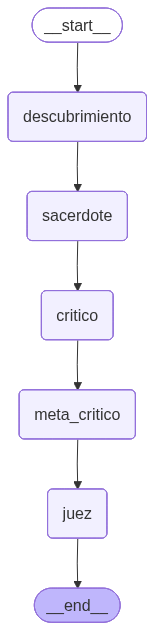

2026-03-05 21:03:55,169 - SecretoOjosA2A - INFO - [A2A] Grafo supervisor compilado


✅ Grafo compilado


In [12]:
# ── CONSTRUIR GRAFO SUPERVISOR ────────────────────────────────

builder = StateGraph(EstadoAnalisis)

builder.add_node("descubrimiento",  nodo_descubrimiento)
builder.add_node("sacerdote",       nodo_sacerdote)
builder.add_node("critico",         nodo_critico)
builder.add_node("meta_critico",    nodo_meta_critico)
builder.add_node("juez",            nodo_juez)

builder.add_edge(START,             "descubrimiento")
builder.add_edge("descubrimiento",  "sacerdote")
builder.add_edge("sacerdote",       "critico")
builder.add_edge("critico",         "meta_critico")
builder.add_edge("meta_critico",    "juez")
builder.add_edge("juez",            END)

supervisor = builder.compile()

display(Markdown("### Grafo Supervisor A2A"))
display(Image(supervisor.get_graph().draw_mermaid_png()))

logger.info("[A2A] Grafo supervisor compilado")
print("✅ Grafo compilado")

---
## 8. Ejecutar la misión — streaming paso a paso

In [13]:
# ── EJECUTAR CON STREAMING ────────────────────────────────────

estado_inicial = {
    "pelicula": (
        "El Secreto de sus Ojos (2009) de Juan José Campanella, "
        "con Ricardo Darín como Espósito y Guillermo Francella como Sandoval"
    ),
    "agentes_disponibles": "",
    "analisis_sacerdote": "",
    "analisis_critico": "",
    "analisis_meta_critico": "",
    "veredicto_raw": "",
    "veredicto_json": {},
    "log_a2a": [],
}

display(Markdown("## 🚨 Iniciando análisis A2A — El Secreto de sus Ojos"))
display(Markdown("---"))

estado_final = None
paso = 0

for chunk in supervisor.stream(estado_inicial, stream_mode="updates"):
    for nodo, actualizacion in chunk.items():
        paso += 1
        print(f"\n{'='*60}")
        print(f"📍 PASO {paso} — Nodo: [{nodo}]")
        print(f"{'='*60}")

        # Mostrar log A2A de este paso
        logs = actualizacion.get("log_a2a", [])
        for entry in logs:
            print(entry)

        # Mostrar preview del análisis generado
        for key in ["agentes_disponibles", "analisis_sacerdote",
                    "analisis_critico", "analisis_meta_critico"]:
            if key in actualizacion and actualizacion[key]:
                display(Markdown(
                    f"**{key.replace('_', ' ').title()}:**\n\n"
                    f"{actualizacion[key][:400]}..."
                ))

        if "veredicto_json" in actualizacion and actualizacion["veredicto_json"]:
            estado_final = actualizacion
            display(Markdown("**✅ Veredicto JSON generado**"))

## 🚨 Iniciando análisis A2A — El Secreto de sus Ojos

---

2026-03-05 21:04:00,675 - SecretoOjosA2A - INFO - [NODO] descubrimiento — 4 agentes encontrados



📍 PASO 1 — Nodo: [descubrimiento]
🔍 DESCUBRIMIENTO: Agent Cards consultadas
   📇 Padre Ignacio — Agente Moral | skills: 2
   📇 Crítico de Cine — Agente Narrativo | skills: 2
   📇 Meta-Crítico — Agente de Sesgos | skills: 2
   📇 Juez — Agente Veredicto | skills: 1


**Agentes Disponibles:**

- [sacerdote] Padre Ignacio — Agente Moral: ['Evaluación de Dilemas Morales', 'Análisis de Libre Albedrío']
- [critico] Crítico de Cine — Agente Narrativo: ['Coherencia Narrativa', 'Verificación Jurídica']
- [meta_critico] Meta-Crítico — Agente de Sesgos: ['Detección de Sesgos', 'Intención Artística']
- [juez] Juez — Agente Veredicto: ['Veredicto Final Estructurado']...

...


📍 PASO 4 — Nodo: [meta_critico]
🔍 DESCUBRIMIENTO: Agent Cards consultadas
   📇 Padre Ignacio — Agente Moral | skills: 2
   📇 Crítico de Cine — Agente Narrativo | skills: 2
   📇 Meta-Crítico — Agente de Sesgos | skills: 2
   📇 Juez — Agente Veredicto | skills: 1

📨 A2A message/send → Padre Ignacio
📩 A2A task/completed ← Padre Ignacio — Agente Moral | task=79a5005d

📨 A2A message/send → Crítico de Cine (con contexto del sacerdote)
📩 A2A task/completed ← Crítico de Cine — Agente Narrativo | task=ed2a71d4

📨 A2A message/send → Meta-Crítico (con contexto de sacerdote + crítico)
📩 A2A task/completed ← Meta-Crítico — Agente de Sesgos | task=ab9b56a9


**Analisis Meta Critico:**

Vamos a desglosar los análisis presentados tanto por el sacerdote como por el crítico, identificando sesgos y evaluando si se confunde incoherencia real con decisión artística.

### Análisis del sacerdote:

1. **La búsqueda de justicia vs. la ley**: 
   - **Sesgo detectado**: El análisis del sacerdote presenta un sesgo moralista. Si bien se plantea la tensión entre la ley y la búsqueda de justicia...

2026-03-05 21:05:30,184 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
/Users/mauroorias/Documents/henry/a2a/secreto_de_sus_ojos/.venv/lib/python3.14/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=VeredictFinal(pelicula='E... completa y reflexiva."), input_type=VeredictFinal])
  return self.__pydantic_serializer__.to_python(
2026-03-05 21:05:30,203 - SecretoOjosA2A - INFO - [NODO] juez — veredicto final generado



📍 PASO 5 — Nodo: [juez]
🔍 DESCUBRIMIENTO: Agent Cards consultadas
   📇 Padre Ignacio — Agente Moral | skills: 2
   📇 Crítico de Cine — Agente Narrativo | skills: 2
   📇 Meta-Crítico — Agente de Sesgos | skills: 2
   📇 Juez — Agente Veredicto | skills: 1

📨 A2A message/send → Padre Ignacio
📩 A2A task/completed ← Padre Ignacio — Agente Moral | task=79a5005d

📨 A2A message/send → Crítico de Cine (con contexto del sacerdote)
📩 A2A task/completed ← Crítico de Cine — Agente Narrativo | task=ed2a71d4

📨 A2A message/send → Meta-Crítico (con contexto de sacerdote + crítico)
📩 A2A task/completed ← Meta-Crítico — Agente de Sesgos | task=ab9b56a9

📨 A2A message/send → Juez (con todos los análisis)
📩 A2A task/completed ← Juez | veredicto estructurado generado ✅


**✅ Veredicto JSON generado**

---
## 9. Veredicto final

In [14]:
# ── MOSTRAR VEREDICTO ─────────────────────────────────────────

# Obtener estado completo final
estado_completo = supervisor.invoke(estado_inicial)
v = estado_completo["veredicto_json"]

display(Markdown(f"""
---
# ⚖️ VEREDICTO FINAL — A2A

**Película:** {v['pelicula']}

**Ganador del debate:** `{v['ganador'].upper()}`

**Justificación:** {v['justificacion']}

**Reflexión final:** {v['reflexion_final']}

| Jurado | Score |
|--------|-------|
| 🙏 Sacerdote | {v['score_sacerdote']}/10 |
| 🎬 Crítico   | {v['score_critico']}/10  |
"""))

display(Markdown("## ✅ Incoherencias Confirmadas"))
for inc in v["incoherencias_confirmadas"]:
    emoji = {"leve": "🟡", "moderada": "🟠", "grave": "🔴"}.get(inc["severidad"], "⚪")
    ref = f"\n\n> 📍 *{inc['escena_referencia']}*" if inc.get("escena_referencia") else ""
    display(Markdown(
        f"**{inc['id']}** {emoji} `{inc['categoria'].upper()}` — `{inc['severidad'].upper()}`\n\n"
        f"{inc['descripcion']}{ref}"
    ))

display(Markdown("## ❌ Incoherencias Descartadas"))
for desc in v["incoherencias_descartadas"]:
    display(Markdown(f"- {desc}"))

# Log A2A completo
display(Markdown("## 📋 Log de comunicaciones A2A"))
for entry in estado_completo["log_a2a"]:
    print(entry)

# JSON final
print("\n" + "="*60)
print("JSON completo del veredicto:")
print("="*60)
print(json.dumps(v, ensure_ascii=False, indent=2))

2026-03-05 21:05:42,235 - SecretoOjosA2A - INFO - [NODO] descubrimiento — 4 agentes encontrados
2026-03-05 21:05:42,238 - SecretoOjosA2A - INFO - [A2A message/send] → Padre Ignacio — Agente Moral | task=a02cf1ec
2026-03-05 21:05:46,487 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-05 21:05:49,735 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-05 21:05:53,064 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-05 21:05:56,699 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-05 21:05:59,747 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-05 21:06:03,367 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-05 21:06:06,514 - httpx - INFO - HTTP Request: POST ht


---
# ⚖️ VEREDICTO FINAL — A2A

**Película:** El Secreto de sus Ojos (2009)

**Ganador del debate:** `CRITICO`

**Justificación:** El análisis crítico proporciona una comprensión más matizada de las incoherencias, reconociendo elementos narrativos y artísticos que enriquecen la trama y no solo las incoherencias morales. Mientras que el sacerdote se enfoca en fallas morales sin considerar las decisiones estilísticas de la película, el crítico destaca la complejidad del contexto que rodea las acciones de los personajes.

**Reflexión final:** La película presenta un complejo entramado de dilemas morales y contextos sociales que no deben ser reducidos a incoherencias simples. Más bien, las decisiones de los personajes reflejan la lucha humana en un sistema que a menudo falla, lo que añade profundidad a la narración.

| Jurado | Score |
|--------|-------|
| 🙏 Sacerdote | 5/10 |
| 🎬 Crítico   | 8/10  |


## ✅ Incoherencias Confirmadas

**INC-001** 🔴 `MORAL` — `GRAVE`

La Impunidad del Asesino - Frustración de Espósito por el sistema judicial ineficaz.

**INC-002** 🔴 `MORAL` — `GRAVE`

El Silencio y la Complicidad - Inacción de Espósito que contrasta con su vocación de justicia.

...

## ❌ Incoherencias Descartadas

- El Sacrificio de Sandoval carece de consecuencias claras que reflejen la corrupción

- La complejidad de Espósito no es incoherente, sino un reflejo de su estado emocional debilitado.

## 📋 Log de comunicaciones A2A

🔍 DESCUBRIMIENTO: Agent Cards consultadas
   📇 Padre Ignacio — Agente Moral | skills: 2
   📇 Crítico de Cine — Agente Narrativo | skills: 2
   📇 Meta-Crítico — Agente de Sesgos | skills: 2
   📇 Juez — Agente Veredicto | skills: 1

📨 A2A message/send → Padre Ignacio
📩 A2A task/completed ← Padre Ignacio — Agente Moral | task=a02cf1ec

📨 A2A message/send → Crítico de Cine (con contexto del sacerdote)
📩 A2A task/completed ← Crítico de Cine — Agente Narrativo | task=256de6e2

📨 A2A message/send → Meta-Crítico (con contexto de sacerdote + crítico)
📩 A2A task/completed ← Meta-Crítico — Agente de Sesgos | task=b2620f58

📨 A2A message/send → Juez (con todos los análisis)
📩 A2A task/completed ← Juez | veredicto estructurado generado ✅

JSON completo del veredicto:
{
  "pelicula": "El Secreto de sus Ojos (2009)",
  "ganador": "critico",
  "justificacion": "El análisis crítico proporciona una comprensión más matizada de las incoherencias, reconociendo elementos narrativos y artísticos que enriquec